In [1]:
# ============================================================
# Smart Document Redaction Tool - FINAL NER + HYBRID SYSTEM
# ============================================================

# ---------------------------
# 1. Install dependencies
# ---------------------------

!pip install -q -U spacy scikit-learn pandas numpy tqdm matplotlib
!python -m spacy download en_core_web_lg
!pip install spacy-lookups-data
print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 109.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 w

In [2]:
!pip install numpy==1.24.4 pandas==2.2.2 scikit-learn==1.3.2 scipy==1.11.4 -q --force-reinstall


  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [13]:
# ---------------------------
# 2. Imports
# ---------------------------

import os
import re
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split

import spacy
from spacy.training import Example
from spacy.scorer import Scorer
from spacy.util import minibatch, fix_random_seed
from spacy.tokens import DocBin


import warnings
warnings.filterwarnings('ignore')


print("spaCy version:", spacy.__version__)

spaCy version: 3.8.11


In [14]:
# ---------------------------
# Config
# ---------------------------

SEED = 42
fix_random_seed(SEED)

DATA_PATH = "spacy_redaction_data.json"

MODEL_DIR = Path("models/ner_model")
BEST_MODEL_DIR = MODEL_DIR / "model-best"
LAST_MODEL_DIR = MODEL_DIR / "model-last"
TRAIN_PATH = "redaction_train.spacy"



N_EPOCHS = 8
BATCH_SIZE = 32
DROPOUT = 0.2

print("Config ready.")

Config ready.


In [15]:
# ============================================================
# 3. Load DocBin Dataset
# ============================================================
nlp = spacy.blank("en")

doc_bin = DocBin().from_disk(TRAIN_PATH)
docs = list(doc_bin.get_docs(nlp.vocab))

print("Loaded docs:", len(docs))

Loaded docs: 281416


In [16]:
# ============================================================
# 4. Train / Validation Split
# ============================================================
random.shuffle(docs)

split = int(0.8 * len(docs))
train_docs = docs[:split]
val_docs = docs[split:]

print("Train:", len(train_docs))
print("Validation:", len(val_docs))

Train: 225132
Validation: 56284


In [17]:
# ============================================================
# 5. Convert Docs to spaCy Examples
# ============================================================
def docs_to_examples(nlp, docs):
    return [
        Example.from_dict(
            nlp.make_doc(doc.text),
            {"entities": [(ent.start_char, ent.end_char, ent.label_) for ent in doc.ents]}
        )
        for doc in docs
    ]

train_examples = docs_to_examples(nlp, train_docs)
val_examples = docs_to_examples(nlp, val_docs)

print("Train examples:", len(train_examples))
print("Validation examples:", len(val_examples))

Train examples: 225132
Validation examples: 56284


In [18]:
# ============================================================
# 6. Load Pretrained Model and Setup NER
# ============================================================
nlp = spacy.load("en_core_web_lg")

# Remove existing NER
if "ner" in nlp.pipe_names:
    nlp.remove_pipe("ner")

# Add fresh NER
ner = nlp.add_pipe("ner")

# Add labels
labels = set()
for doc in train_docs:
    for ent in doc.ents:
        labels.add(ent.label_)

for label in labels:
    ner.add_label(label)

optimizer = nlp.initialize()

print("NER Labels:", labels)

NER Labels: {'EMAIL', 'PERSON', 'LOCATION', 'IP_ADDRESS', 'URL_TOKEN', 'ID', 'PASSPORT', 'DATE', 'PERCENT', 'ORGANIZATION', 'TIME', 'MONEY', 'PHONE', 'CREDIT_CARD'}


In [19]:
# ============================================================
# 7. Evaluation Function
# ============================================================
from spacy.scorer import Scorer

def evaluate(nlp, examples):
    scorer = Scorer()
    preds = []

    for ex in examples:
        pred = nlp(ex.reference.text)
        preds.append(Example(pred, ex.reference))

    return scorer.score(preds)

In [12]:
# ============================================================
# 8. Training Loop (WITH PROGRESS + ETA + HISTORY)
# ============================================================
import time
import math
from datetime import timedelta

other_pipes = [p for p in nlp.pipe_names if p != "ner"]

best_f1 = -1
history = []

print("\n========== TRAINING START ==========")
print("Total epochs:", N_EPOCHS)
print("Train examples:", len(train_examples))
print("Batch size:", BATCH_SIZE)

start_training_time = time.time()

with nlp.disable_pipes(*other_pipes):

    for epoch in range(N_EPOCHS):
        epoch_start = time.time()
        random.shuffle(train_examples)
        losses = {}

        batches = minibatch(train_examples, size=BATCH_SIZE)
        total_batches = math.ceil(len(train_examples) / BATCH_SIZE)

        print(f"\n🔹 Epoch {epoch+1}/{N_EPOCHS} | Total batches: {total_batches}")

        batch_start_time = time.time()

        for i, batch in enumerate(batches):
            nlp.update(batch, drop=DROPOUT, losses=losses)

            # Progress update
            if (i + 1) % 100 == 0 or (i + 1) == total_batches:
                elapsed = time.time() - batch_start_time
                avg_time = elapsed / (i + 1)
                remaining_batches = total_batches - (i + 1)
                eta = remaining_batches * avg_time

                print(f"Batch {i+1}/{total_batches} "
                      f"| Avg batch: {avg_time:.2f}s "
                      f"| ETA: {timedelta(seconds=int(eta))}")

        epoch_time = time.time() - epoch_start

        print(f"\n✅ Epoch {epoch+1} finished")
        print("Loss:", losses["ner"])
        print("Epoch time:", timedelta(seconds=int(epoch_time)))

        # Evaluation
        scores = evaluate(nlp, val_examples)
        f1 = scores["ents_f"]

        print("Precision:", round(scores["ents_p"], 4))
        print("Recall   :", round(scores["ents_r"], 4))
        print("F1       :", round(f1, 4))

        # Store history for plotting
        history.append((epoch, losses["ner"], f1))

        # Save BEST model only (cleaner)
        if f1 > best_f1:
            best_f1 = f1
            BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
            nlp.to_disk(BEST_MODEL_DIR)
            print("🔥 Saved BEST model!")

        # Training ETA summary
        elapsed_total = time.time() - start_training_time
        avg_epoch_time = elapsed_total / (epoch + 1)
        remaining_epochs = N_EPOCHS - (epoch + 1)
        total_eta = remaining_epochs * avg_epoch_time

        print("\n📊 Training Progress Summary:")
        print(f"Elapsed total time: {timedelta(seconds=int(elapsed_total))}")
        print(f"Avg epoch time   : {timedelta(seconds=int(avg_epoch_time))}")
        print(f"Remaining epochs : {remaining_epochs}")
        print(f"Estimated remaining time: {timedelta(seconds=int(total_eta))}")

print("\n========== TRAINING COMPLETE ==========")
print("Best validation F1:", round(best_f1, 4))


========== TRAINING START ==========
Total epochs: 8
Train examples: 225132
Batch size: 32

🔹 Epoch 1/8 | Total batches: 7036
Batch 100/7036 | Avg batch: 0.10s | ETA: 0:11:48
Batch 200/7036 | Avg batch: 0.10s | ETA: 0:11:35
Batch 300/7036 | Avg batch: 0.10s | ETA: 0:11:11
Batch 400/7036 | Avg batch: 0.10s | ETA: 0:10:51
Batch 500/7036 | Avg batch: 0.10s | ETA: 0:10:46
Batch 600/7036 | Avg batch: 0.10s | ETA: 0:10:41
Batch 700/7036 | Avg batch: 0.10s | ETA: 0:10:33
Batch 800/7036 | Avg batch: 0.10s | ETA: 0:10:16
Batch 900/7036 | Avg batch: 0.10s | ETA: 0:10:09
Batch 1000/7036 | Avg batch: 0.10s | ETA: 0:10:00
Batch 1100/7036 | Avg batch: 0.10s | ETA: 0:09:52
Batch 1200/7036 | Avg batch: 0.10s | ETA: 0:09:42
Batch 1300/7036 | Avg batch: 0.10s | ETA: 0:09:30
Batch 1400/7036 | Avg batch: 0.10s | ETA: 0:09:22
Batch 1500/7036 | Avg batch: 0.10s | ETA: 0:09:13
Batch 1600/7036 | Avg batch: 0.10s | ETA: 0:09:04
Batch 1700/7036 | Avg batch: 0.10s | ETA: 0:08:53
Batch 1800/7036 | Avg batch: 0.1

In [20]:
# ============================================================
# 9. Load Best Model
# ============================================================
nlp = spacy.load(BEST_MODEL_DIR)

print("Best model loaded successfully.")

Best model loaded successfully.


In [21]:
# ============================================================
# 10. Regex Detectors
# ============================================================
import re

REGEX_PATTERNS = {
    "EMAIL": r"\b[\w\.-]+@[\w\.-]+\.\w+\b",
    "PHONE": r"\b(?:\+?\d{1,3})?\d{8,15}\b",
    "CREDIT_CARD": r"\b\d{13,16}\b",
    "ID": r"\b[A-Z0-9]{6,12}\b"
}

def detect_regex(text):
    results = []
    for label, pattern in REGEX_PATTERNS.items():
        for m in re.finditer(pattern, text):
            results.append({
                "text": m.group(),
                "label": label,
                "start": m.start(),
                "end": m.end()
            })
    return results

In [22]:
# ============================================================
# 11. Merge Entities (NER + Regex)
# ============================================================
def merge_entities(ner, regex):
    all_e = ner + regex
    all_e = sorted(all_e, key=lambda x: (x["start"], -x["end"]))

    final = []
    last_end = -1

    for e in all_e:
        if e["start"] >= last_end:
            final.append(e)
            last_end = e["end"]

    return final

In [23]:
# ============================================================
# 12. Detect Entities (NER + Regex)
# ============================================================
STOPWORDS = {"email", "contact"}

def detect_entities(text):
    doc = nlp(text)

    ner_entities = []
    for ent in doc.ents:
        if ent.text.lower() in STOPWORDS:
            continue
        if ent.text.isdigit():
            continue

        ner_entities.append({
            "text": ent.text,
            "label": ent.label_.upper(),
            "start": ent.start_char,
            "end": ent.end_char
        })

    regex_entities = detect_regex(text)

    return merge_entities(ner_entities, regex_entities)

In [24]:
# ============================================================
# 13. Redaction Function
# ============================================================
def redact(text):
    ents = detect_entities(text)

    for e in sorted(ents, key=lambda x: x["start"], reverse=True):
        text = text[:e["start"]] + f"[REDACTED_{e['label']}]" + text[e["end"]:]

    return text

In [25]:
# ============================================================
# 14. Testing the System
# ============================================================
samples = [
    "John lives in Qatar. Email: john@gmail.com",
    "my name is ahmed and my card is 1234567890123456",
    "Sarah paid 500 dollars",
    "Contact me at 5551234567",
]

for s in samples:
    print("\nTEXT:", s)
    print("ENTITIES:", detect_entities(s))
    print("REDACTED:", redact(s))


TEXT: John lives in Qatar. Email: john@gmail.com
ENTITIES: [{'text': 'John', 'label': 'PERSON', 'start': 0, 'end': 4}, {'text': 'Qatar', 'label': 'LOCATION', 'start': 14, 'end': 19}, {'text': 'john@gmail.com', 'label': 'EMAIL', 'start': 28, 'end': 42}]
REDACTED: [REDACTED_PERSON] lives in [REDACTED_LOCATION]. Email: [REDACTED_EMAIL]

TEXT: my name is ahmed and my card is 1234567890123456
ENTITIES: [{'text': 'ahmed', 'label': 'PERSON', 'start': 11, 'end': 16}, {'text': '1234567890123456', 'label': 'PHONE', 'start': 32, 'end': 48}]
REDACTED: my name is [REDACTED_PERSON] and my card is [REDACTED_PHONE]

TEXT: Sarah paid 500 dollars
ENTITIES: [{'text': 'Sarah', 'label': 'PERSON', 'start': 0, 'end': 5}]
REDACTED: [REDACTED_PERSON] paid 500 dollars

TEXT: Contact me at 5551234567
ENTITIES: [{'text': '5551234567', 'label': 'PHONE', 'start': 14, 'end': 24}]
REDACTED: Contact me at [REDACTED_PHONE]


In [29]:
# ============================================================
# 15. Download Trained Model
# ============================================================
from google.colab import files
import shutil

shutil.make_archive("ner_model", 'zip', BEST_MODEL_DIR)
files.download("ner_model.zip")

print("Model exported and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model exported and downloaded.


In [27]:
# ============================================================
# 16. Error Analysis (FIXED VERSION)
# ============================================================

# Normalize labels (optional safety)
LABEL_NORMALIZATION = {
    "GPE": "LOCATION",
    "LOC": "LOCATION",
}

def normalize_label(label):
    return LABEL_NORMALIZATION.get(label, label)

# Predicted → (text, label)
def normalize_pred(doc):
    return set(
        (ent.text.lower(), normalize_label(ent.label_))
        for ent in doc.ents
    )

# Ground truth → (text, label)
def normalize_true(doc):
    return set(
        (ent.text.lower(), normalize_label(ent.label_))
        for ent in doc.ents
    )

def error_analysis(nlp, docs, n=20):
    print("\n--- ERROR ANALYSIS ---\n")

    errors = []

    for doc in docs:
        pred_doc = nlp(doc.text)

        pred_set = normalize_pred(pred_doc)
        true_set = normalize_true(doc)

        if pred_set != true_set:
            errors.append((doc.text, pred_set, true_set))

    print(f"Total errors: {len(errors)} / {len(docs)}\n")

    for i, (text, pred, true) in enumerate(errors[:n]):
        print("=" * 80)
        print(f"Example {i+1}")

        print("\nTEXT:\n", text)

        print("\nPREDICTED:")
        print(pred)

        print("\nTRUE:")
        print(true)

        print("\nMISSED (in TRUE but not predicted):")
        print(true - pred)

        print("\nEXTRA (predicted but not in TRUE):")
        print(pred - true)

        print("=" * 80)

# Run on validation set
error_analysis(nlp, val_docs, n=20)


--- ERROR ANALYSIS ---

Total errors: 11350 / 56284

Example 1

TEXT:
 The quarterly report sent to U.S. Congress based its information on statistics from the U.S. Labor Department compiled from workers ' compensation claims filed by all U.S. government contractors.

PREDICTED:
{('u.s. labor department', 'ORGANIZATION'), ('u.s.', 'LOCATION'), ('u.s. congress', 'ORGANIZATION')}

TRUE:
{('u.s. labor department', 'ORGANIZATION'), ('u.s.', 'ORGANIZATION'), ('u.s. congress', 'ORGANIZATION')}

MISSED (in TRUE but not predicted):
{('u.s.', 'ORGANIZATION')}

EXTRA (predicted but not in TRUE):
{('u.s.', 'LOCATION')}
Example 2

TEXT:
 Friday's report from a business group, The National Association of Realtors, says sales of previously-owned homes fell one percent in March.

PREDICTED:
{('friday', 'DATE'), ('national association of realtors', 'ORGANIZATION'), ('march', 'DATE')}

TRUE:
{('friday', 'DATE'), ('the national association of realtors', 'ORGANIZATION'), ('march', 'DATE')}

MISSED (in TR

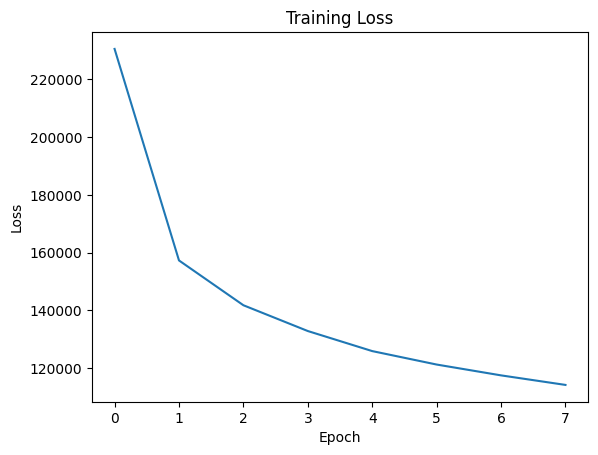

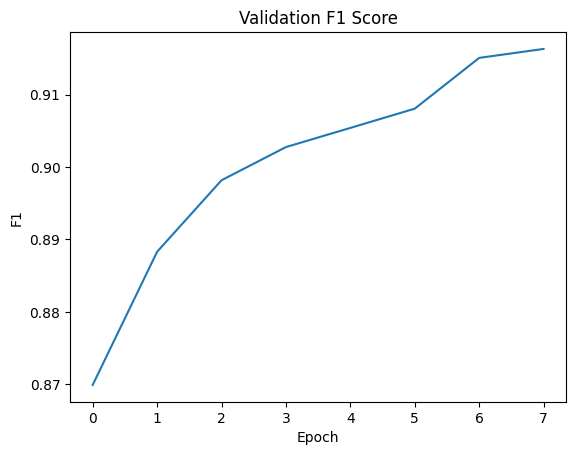


ALL DONE ✅


In [30]:
# ============================================================
# 17. Plot Training Curves
# ============================================================
import matplotlib.pyplot as plt

epochs = [h[0] for h in history]
losses = [h[1] for h in history]
f1s = [h[2] for h in history]

# Loss
plt.figure()
plt.plot(epochs, losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# F1 Score
plt.figure()
plt.plot(epochs, f1s)
plt.title("Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.show()

print("\nALL DONE ✅")